This notebook goes through and demonstrates the current library-backed worflow using a small synthetic ground track and station set. Overall, it validates that box generation, station filtering, and plotting works without relying on the live downloads or the retrieval of any orbital data.

In [1]:
from datetime import datetime, timedelta

from reentry_seismo.types import TrackPoint
from reentry_seismo.tiling import track_to_box_windows
from reentry_seismo.stations import filter_stations_by_track_distance
from reentry_seismo.plotting import plot_track_and_boxes, plot_station_comparison

Build a small synthetic track

In [2]:
t0 = datetime(2024, 4, 2, 8, 40, 0)

track_points = [
    TrackPoint(time=t0 + timedelta(minutes=0), lat=34.0, lon=-120.0),
    TrackPoint(time=t0 + timedelta(minutes=2), lat=35.0, lon=-118.0),
    TrackPoint(time=t0 + timedelta(minutes=4), lat=36.5, lon=-115.0),
    TrackPoint(time=t0 + timedelta(minutes=6), lat=38.0, lon=-110.0),
    TrackPoint(time=t0 + timedelta(minutes=8), lat=39.5, lon=-104.0),
    TrackPoint(time=t0 + timedelta(minutes=10), lat=40.5, lon=-97.0),
]

Make a small station list

In [3]:
stations = [
    {"network": "XX", "station": "STA1", "lat": 34.2, "lon": -119.5},
    {"network": "XX", "station": "STA2", "lat": 35.1, "lon": -117.7},
    {"network": "XX", "station": "STA3", "lat": 39.8, "lon": -103.5},
    {"network": "XX", "station": "STA4", "lat": 44.0, "lon": -90.0},
    {"network": "XX", "station": "STA5", "lat": 30.0, "lon": -100.0},
]

Generate boxes

In [4]:
box_windows = track_to_box_windows(
    track_points,
    chunk_km=300.0,
    overlap_km=50.0,
    corridor_km=100.0,
    pre_pad_minutes=2,
    post_pad_minutes=13,
)

print("Track points:", len(track_points))
print("Boxes generated:", len(box_windows))

Track points: 6
Boxes generated: 4


Filter stations

In [5]:
filtered_stations = filter_stations_by_track_distance(
    stations,
    track_points,
    corridor_km=100.0,
)

print("All stations:", len(stations))
print("Filtered stations:", len(filtered_stations))

All stations: 5
Filtered stations: 3


Plot boxes

c:\Users\josep\OneDrive\Desktop\Johns_Hopkins\Research\reentry-seismo\.venv\Lib\site-packages\cartopy\io\__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
c:\Users\josep\OneDrive\Desktop\Johns_Hopkins\Research\reentry-seismo\.venv\Lib\site-packages\cartopy\io\__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
c:\Users\josep\OneDrive\Desktop\Johns_Hopkins\Research\reentry-seismo\.venv\Lib\site-packages\cartopy\io\__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
c:\Users\josep\OneDrive\Desktop\Johns_Hopkins\Research\reentry-seismo\.venv\Lib\site-packages\cartopy\io\__init__.py:242: DownloadWarning: Downloading: https://naturalea

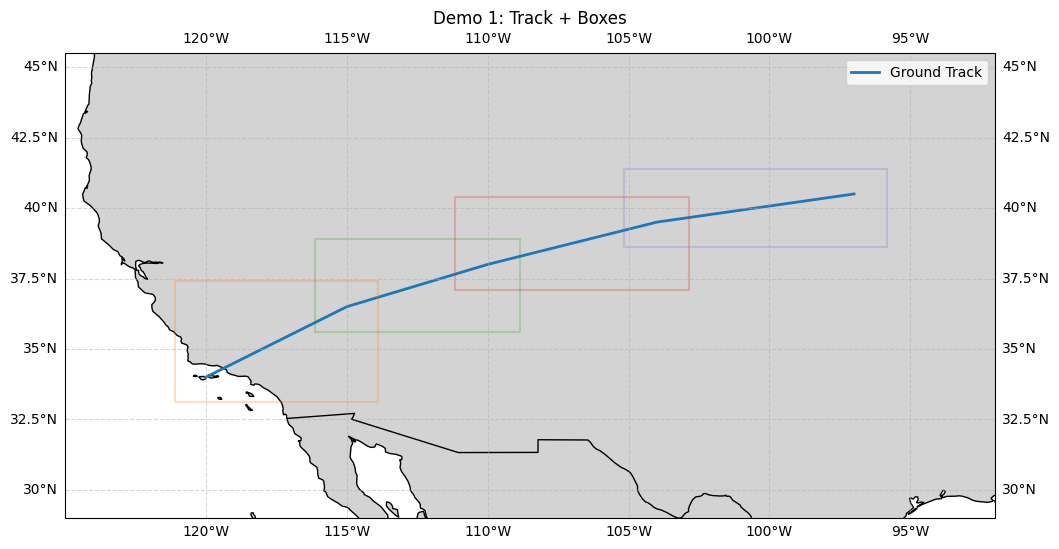

In [6]:
plot_track_and_boxes(
    track_points,
    box_windows,
    title="Demo 1: Track + Boxes",
)

Plot station comparison

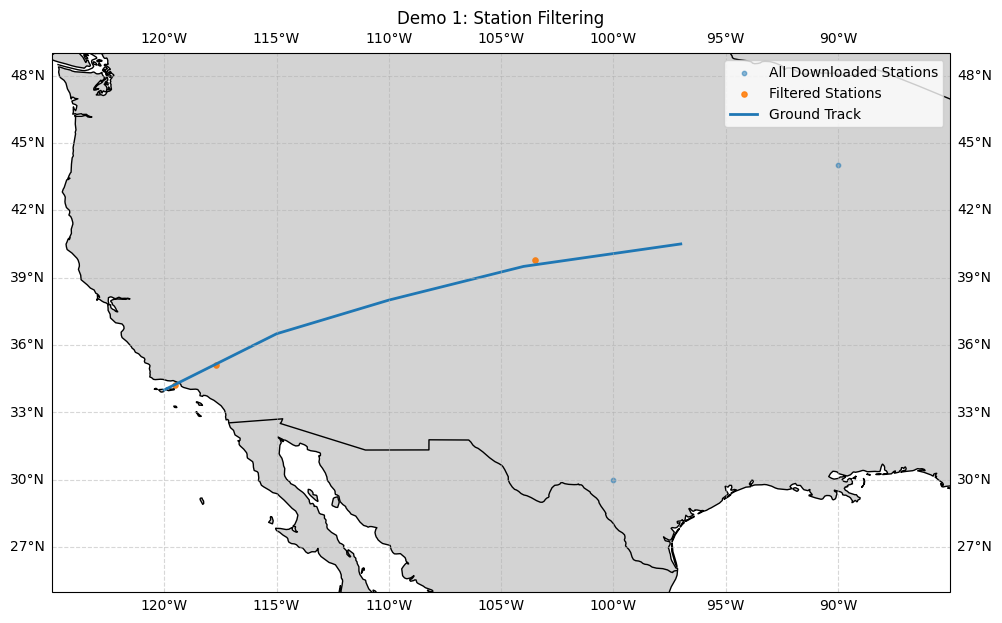

In [7]:
plot_station_comparison(
    stations,
    filtered_stations,
    track_points,
    title="Demo 1: Station Filtering",
)